# Demographic Collapse - Contrarian Audit (Notebook 8)

**Author**: kj  **Approach**: attack the model's own conclusions with 25 pre-registered contrarian hypotheses

A model that only confirms itself has not been tested. This notebook takes a deliberately adversarial stance
toward the findings of Notebooks 3-7 and asks, for each, whether it survives a direct attack. The convention
is inverted on purpose: **SUPPORTED means the contrarian claim holds** - the original finding is *qualified* -
and **REFUTED means the finding survived** the attack. The point is not to win but to locate exactly how far
each conclusion can be trusted.

## Approach
1. **Eight batches** - momentum & predictability, tempo/quantum, migration, interventions, the manifold/eigenstructure, the recalibration, baselines/framing, and deep/semantic critiques
2. **Every hypothesis is a computation** - each contrarian claim is settled by a number from the same UN WPP data and the same core model, not by argument
3. **Honest scoring** - a scorecard tallies which findings were qualified and which survived, and the conclusions state what the audit changed

## Output
- `reports/figures/nb8_contrarian_scorecard.png` (25-cell survive/qualify grid), `nb8_qualified_findings.png` (the strongest qualifications)
- `reports/nb8_contrarian_verdicts.json`
- E13 verdicts recorded into `docs/experiments/demographic-collapse-experiments.md`


## GPU selection

Pin the RTX PRO 4000 Blackwell by UUID before importing torch (via coremodel).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"


## Imports

In [2]:
import numpy as np
import torch
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from scipy.stats import spearmanr
from rich.console import Console
from rich.table import Table
from rich import box
from sci_demographic_collapse import coremodel as cm
console = Console()
%matplotlib inline
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10, "axes.titleweight": "bold"})


2026-07-06 16:23:52.071 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
console.print(f"[green]seeds set[/green] = {SEED}; device = {cm.DEV}")


seeds set = 0; device = cuda

## Configuration

Data window, device, and the verdict store. Convention: SUPPORTED = contrarian holds (finding qualified); REFUTED = finding survived.

In [4]:
PROJ = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True); REPORTS = PROJ / "reports"
REG = cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"), y0=1990, y1=2023)
Y0 = 1990; DEV = cm.DEV; RC = cm.rogers_castro()
V = {}   # verdict store: id -> (verdict, claim, evidence)
def rec(k, claim, supported, ev):
    V[k] = ("SUPPORTED" if supported else "REFUTED", claim, ev)
def show(batch, ids):
    tb = Table(title=batch, box=box.ROUNDED); tb.add_column("id"); tb.add_column("verdict"); tb.add_column("contrarian claim -> evidence", max_width=96)
    col = {"SUPPORTED": "yellow", "REFUTED": "green"}
    for k in ids:
        vd, cl, ev = V[k]; tag = "qualified" if vd == "SUPPORTED" else "survived"
        tb.add_row(k, f"[{col[vd]}]{vd}[/{col[vd]}] ({tag})", ev)
    console.print(tb)
console.print(f"[green]loaded[/green] {len(REG)} regions, window {Y0}-2023")


loaded 10 regions, window 1990-2023

## Machinery

Forward projection (Notebook 6), the Bongaarts-Feeney tempo factor, and a compact Wasserstein fit (Notebook 7) reused for the overfitting probes.

In [5]:
def recent_mig(nm): R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))
def forward(nm, tfr_future, mig_annual, years=77, surv_improve=0.003):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); shape = R["asfr"][-1].copy(); st = shape.sum()
    tot = np.zeros(years+1); tot[0] = float(nf.sum()+nm_.sum())
    for t in range(years):
        Sx = 1 - (1-Sx0)*(1-surv_improve)**(t+1)
        asfr = shape*(tfr_future[t]/st) if st > 1e-6 else shape
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, device=DEV), torch.tensor(asfr, device=DEV), srb, torch.tensor(mig_annual*RC, device=DEV))
        tot[t+1] = float(nf.sum()+nm_.sum())
    return tot
def bf(R):
    tfr = R["ind"]["TFR"]; mac = R["ind"]["MAC"]; macs = np.convolve(mac, np.ones(3)/3, mode="same"); macs[0] = mac[0]; macs[-1] = mac[-1]
    return tfr, np.gradient(macs)
def w2_1d(z, prior): zs, _ = torch.sort(z); ps, _ = torch.sort(prior[:len(z)]); return ((zs-ps)**2).mean()
def fit_w2(tfr, r, tmax_idx, steps=2000, seed=0):
    torch.manual_seed(seed); T = len(tfr); t = np.arange(T).astype(float)
    tt = torch.tensor(t, device=DEV); rr = torch.tensor(r, device=DEV); yy = torch.tensor(tfr, device=DEV)
    mask = torch.tensor((t <= tmax_idx).astype(float), device=DEV)
    p = dict(l0=torch.tensor(2.0, requires_grad=True, device=DEV), dr=torch.tensor(-0.01, requires_grad=True, device=DEV),
             lt=torch.tensor(np.log(0.05), requires_grad=True, device=DEV), ls=torch.tensor(np.log(0.1), requires_grad=True, device=DEV),
             zm=torch.zeros(T, requires_grad=True, device=DEV), zl=torch.full((T,), np.log(0.3), requires_grad=True, device=DEV))
    opt = torch.optim.Adam(list(p.values()), lr=0.02); prior = torch.randn(2000, device=DEV)
    for _ in range(steps):
        opt.zero_grad(); z = p["zm"] + torch.exp(p["zl"])*torch.randn(T, device=DEV)
        q = p["l0"] + p["dr"]*tt + torch.exp(p["lt"])*torch.cumsum(z, 0); pred = q*(1-rr); sig = torch.exp(p["ls"])
        recon = (((yy-pred)/sig)**2*mask).sum()*0.5 + mask.sum()*p["ls"]
        (recon + 5.0*w2_1d(z, prior)*T).backward(); opt.step()
    with torch.no_grad(): med = ((p["l0"]+p["dr"]*tt+torch.exp(p["lt"])*torch.cumsum(p["zm"], 0))*(1-rr)).cpu().numpy()
    return med
console.print("[green]machinery ready[/green]")


machinery ready

## Batch CA - momentum and population predictability

Three attacks on the headline claim that *momentum governs timing and depth* and *population is predictable*:
that a trivial persistence baseline is just as good (C1), that momentum is not a stable regional constant (C2),
and that the USA's predictability is really migration persistence, not age-structure momentum (C3).

In [6]:
R = REG["USA"]; nmg = R["ind"]["PopChange"] - R["ind"]["NatChange"]
run = cm.project(R, mig_schedule=lambda k: nmg[k]*RC); obs = R["ind"]["TPopulation1Jan"]; test = R["years"] > 2015
model_mape = cm.mape(run["total"][test], obs[test])
persist = np.full(int(test.sum()), obs[R["years"] == 2015][0]); persist_mape = cm.mape(persist, obs[test])
rec("E13-C1", "persistence is as good as the age-structured model for 8-yr population", persist_mape <= model_mape*1.5,
    f"model pop MAPE {model_mape:.2f}% vs hold-2015-flat {persist_mape:.2f}% - age structure earns its place")
moms = [cm.keyfitz_momentum(REG["USA"], k)[0] for k in [0, 15, 33]]
rec("E13-C2", "Keyfitz momentum is not a stable regional constant (it depends on base year)", (max(moms)-min(moms)) > 0.05,
    f"USA momentum 1990/2005/2023 = {moms[0]:.2f}/{moms[1]:.2f}/{moms[2]:.2f} (range {max(moms)-min(moms):.2f}) - momentum depletes")
nat = nmg  # for clarity
natc = R["ind"]["NatChange"][test].sum(); migc = nmg[test].sum()
rec("E13-C3", "USA 'population predictability' is migration persistence, not age-structure momentum", abs(migc) >= abs(natc),
    f"2016-23 cumulative natural {natc:.0f}k vs migration {migc:.0f}k - migration dominates the USA change")
show("Batch CA - momentum & predictability", ["E13-C1", "E13-C2", "E13-C3"])


                                       Batch CA - momentum & predictability                                        
╭────────┬───────────────────────┬────────────────────────────────────────────────────────────────────────────────╮
│ id     │ verdict               │ contrarian claim -> evidence                                                   │
├────────┼───────────────────────┼────────────────────────────────────────────────────────────────────────────────┤
│ E13-C1 │ REFUTED (survived)    │ model pop MAPE 0.09% vs hold-2015-flat 3.45% - age structure earns its place   │
│ E13-C2 │ SUPPORTED (qualified) │ USA momentum 1990/2005/2023 = 1.09/1.05/0.98 (range 0.10) - momentum depletes  │
│ E13-C3 │ SUPPORTED (qualified) │ 2016-23 cumulative natural 5915k vs migration 10940k - migration dominates the │
│        │                       │ USA change                                                                     │
╰────────┴───────────────────────┴────────────────────────────────────────────────────────────────────────────────╯

## Batch CB - tempo and quantum

Attacks on the tempo-quantum story: that the USA shortfall is not pure recoverable tempo because its quantum
is itself falling (C4), that the Bongaarts-Feeney split is fragile (C5), and that Korea's deficit is partly
postponement too (C6).

In [7]:
def adjtfr(R): tfr, r = bf(R); return tfr/(1-r)
aU = adjtfr(REG["USA"]); yrs = REG["USA"]["years"]; m = yrs >= 2010; sl = np.polyfit(yrs[m], aU[m], 1)[0]
rec("E13-C4", "the USA shortfall is not pure recoverable tempo - its quantum (adjTFR) is itself falling since 2010", sl < -0.005,
    f"USA adjTFR slope 2010-23 = {sl:+.3f}/yr - quantum declining, not just postponement (tempo estimates noisy)")
_, rU = bf(REG["USA"]); flips = int(np.sum(np.diff(np.sign(rU)) != 0))
rec("E13-C5", "the tempo/quantum split is fragile - r=d(MAC)/dt is noisy and flips sign repeatedly", flips >= 5,
    f"USA r sign-flips {flips} over 34 yrs, std {np.std(rU):.3f} - the mean age rises monotonically, split is stable")
_, rK = bf(REG["Korea"]); rK_recent = float(np.mean(rK[-8:]))
rec("E13-C6", "Korea's deficit is partly tempo too - its mean age at childbearing is still rising", rK_recent > 0.02,
    f"Korea recent r = {rK_recent:+.3f}/yr - postponement ongoing, so not a pure quantum deficit")
show("Batch CB - tempo & quantum", ["E13-C4", "E13-C5", "E13-C6"])


                                            Batch CB - tempo & quantum                                             
╭────────┬───────────────────────┬────────────────────────────────────────────────────────────────────────────────╮
│ id     │ verdict               │ contrarian claim -> evidence                                                   │
├────────┼───────────────────────┼────────────────────────────────────────────────────────────────────────────────┤
│ E13-C4 │ SUPPORTED (qualified) │ USA adjTFR slope 2010-23 = -0.050/yr - quantum declining, not just             │
│        │                       │ postponement (tempo estimates noisy)                                           │
│ E13-C5 │ REFUTED (survived)    │ USA r sign-flips 0 over 34 yrs, std 0.045 - the mean age rises monotonically,  │
│        │                       │ split is stable                                                                │
│ E13-C6 │ SUPPORTED (qualified) │ Korea recent r = +0.194/yr - postponement ongoing, so not a pure quantum       │
│        │                       │ deficit                                                                        │
╰────────┴───────────────────────┴────────────────────────────────────────────────────────────────────────────────╯

## Batch CC - migration

Attacks on the migration treatment: that the Rogers-Castro age shape is unnecessary for the population total
(C7), that migration rather than fertility is the USA master variable (C8), and that the childhood-echo term
is redundant (C9).

In [8]:
def totresid_sched(nm, sched):
    R = REG[nm]; g = R["ind"]["PopChange"] - R["ind"]["NatChange"]
    run = cm.project(R, mig_schedule=lambda k: g[k]*sched); return abs(run["total"][-1]-R["ind"]["TPopulation1Jan"][-1])/R["ind"]["TPopulation1Jan"][-1]*100
uniform = np.full(cm.NA, 1.0/cm.NA)
rcr, unr = totresid_sched("USA", RC), totresid_sched("USA", uniform)
rec("E13-C7", "Rogers-Castro is unnecessary for the population TOTAL - a scalar (age-uniform) migration matches it", abs(unr-rcr) < 0.1,
    f"USA total residual: RC {rcr:.3f}% vs age-uniform {unr:.3f}% - the age shape matters even for the headline total")
tfr0 = float(REG['USA']['ind']['TFR'][-1]); mig0 = recent_mig("USA")
base = forward("USA", np.full(77, tfr0), mig0); tfr_up = forward("USA", np.full(77, tfr0+0.3), mig0); mig_up = forward("USA", np.full(77, tfr0), mig0*1.5)
dfe = (tfr_up[-1]-base[-1])/1e3; dmi = (mig_up[-1]-base[-1])/1e3
rec("E13-C8", "migration, not fertility, is the USA master variable to 2100 (+50% migration beats +0.3 TFR)", dmi >= dfe,
    f"USA 2100: +0.3 TFR {dfe:+.1f}M vs +50% migration {dmi:+.1f}M - fertility is the stronger lever")
labour_only = cm.rogers_castro(a1=0.0); rc_lab = totresid_sched("USA", labour_only)
rec("E13-C9", "the Rogers-Castro childhood-echo term is redundant - a labour-peak-only schedule matches the total", abs(rc_lab-rcr) < 0.15,
    f"USA total residual: RC-full {rcr:.3f}% vs labour-only {rc_lab:.3f}% - the echo earns its place")
show("Batch CC - migration", ["E13-C7", "E13-C8", "E13-C9"])


                                               Batch CC - migration                                                
╭────────┬────────────────────┬───────────────────────────────────────────────────────────────────────────────────╮
│ id     │ verdict            │ contrarian claim -> evidence                                                      │
├────────┼────────────────────┼───────────────────────────────────────────────────────────────────────────────────┤
│ E13-C7 │ REFUTED (survived) │ USA total residual: RC 0.228% vs age-uniform 6.451% - the age shape matters even  │
│        │                    │ for the headline total                                                            │
│ E13-C8 │ REFUTED (survived) │ USA 2100: +0.3 TFR +85.9M vs +50% migration +61.7M - fertility is the stronger    │
│        │                    │ lever                                                                             │
│ E13-C9 │ REFUTED (survived) │ USA total residual: RC-full 0.228% vs labour-only 0.889% - the echo earns its     │
│        │                    │ place                                                                             │
╰────────┴────────────────────┴───────────────────────────────────────────────────────────────────────────────────╯

## Batch CD - interventions

Attacks on the intervention conclusions: that a modest lift is futile for Korea (C10), that a migration lever
dominates any fertility intervention for the USA (C11), that timing barely matters at 2100 (C12), and that the
'momentum locks the near term' claim is just arithmetic (C13).

In [9]:
kb = forward("Korea", np.full(77, 0.72), recent_mig("Korea")); ku = forward("Korea", np.full(77, 0.72+0.3), recent_mig("Korea"))
loss = REG["Korea"]["ind"]["TPopulation1Jan"][-1]-kb[-1]; frac = (ku[-1]-kb[-1])/loss*100
rec("E13-C10", "a modest (+0.3) fertility lift is futile for Korea - it recovers a tiny fraction of the baseline loss", frac < 15,
    f"Korea +0.3 TFR recovers {frac:.0f}% of the {loss/1e3:.0f}M baseline loss - modest but non-trivial")
rec("E13-C11", "for the USA a migration lever dominates any fertility intervention to 2100", dmi >= dfe,
    f"USA 2100 levers: migration {dmi:+.1f}M vs fertility {dfe:+.1f}M - fertility is competitive, not dominated")
ke = forward("Korea", np.concatenate([np.linspace(0.72, 2.1, 10), np.full(67, 2.1)]), recent_mig("Korea"))
kl = forward("Korea", np.concatenate([np.full(20, 0.72), np.linspace(0.72, 2.1, 10), np.full(47, 2.1)]), recent_mig("Korea"))
tim = (ke[-1]-kl[-1])/ke[-1]*100
rec("E13-C12", "intervention timing barely matters at the 2100 horizon (2025 vs 2045 start)", abs(tim) < 10,
    f"Korea early-vs-late structural lift differ {tim:.0f}% of 2100 pop - timing is decisive, not minor")
def frac_births_prealive(nm, horizon=27):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); asfr = torch.tensor(R["asfr"][-1].copy(), device=DEV)
    for t in range(horizon):
        Sx = torch.tensor(1-(1-Sx0)*(1-0.003)**(t+1), device=DEV); nf, nm_, _, _ = cm.leslie_step(nf, nm_, Sx, asfr, srb, None)
    bba = R["asfr"][-1]*nf.cpu().numpy(); return bba[27:].sum()/bba.sum()
fpre = frac_births_prealive("Korea")
rec("E13-C13", "'momentum locks the near term' is arithmetic, not insight - 2050's mothers are already born", fpre > 0.75,
    f"{fpre*100:.0f}% of Korea's 2050 births come from women already alive in 2023 - the near-term lock is arithmetic")
show("Batch CD - interventions", ["E13-C10", "E13-C11", "E13-C12", "E13-C13"])


                                             Batch CD - interventions                                              
╭─────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict               │ contrarian claim -> evidence                                                  │
├─────────┼───────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ E13-C10 │ REFUTED (survived)    │ Korea +0.3 TFR recovers 18% of the 32M baseline loss - modest but non-trivial │
│ E13-C11 │ REFUTED (survived)    │ USA 2100 levers: migration +61.7M vs fertility +85.9M - fertility is          │
│         │                       │ competitive, not dominated                                                    │
│ E13-C12 │ REFUTED (survived)    │ Korea early-vs-late structural lift differ 34% of 2100 pop - timing is        │
│         │                       │ decisive, not minor                                                           │
│ E13-C13 │ SUPPORTED (qualified) │ 97% of Korea's 2050 births come from women already alive in 2023 - the        │
│         │                       │ near-term lock is arithmetic                                                  │
╰─────────┴───────────────────────┴───────────────────────────────────────────────────────────────────────────────╯

## Batch CE - the manifold and eigenstructure

Attacks on the structural claims: that the 'TFR-1.5 trap ridge' is behavioural lore rather than the Leslie
replacement threshold (C14), that the eigenvalue does not order strictly by TFR (C15), and that migration
wrecks the stable-pyramid match (C16).

In [10]:
def tfr_at_replacement(nm, k=-1):
    R = REG[nm]; shape = R["asfr"][k]; s = shape.sum(); lo, hi = 0.5, 5.0
    for _ in range(40):
        mid = (lo+hi)/2; nr = cm.nrr(shape*(mid/s), R["Sx"][k], float(R["ind"]["SRB"][k]))
        lo, hi = (mid, hi) if nr < 1 else (lo, mid)
    return (lo+hi)/2
trep = tfr_at_replacement("USA")
rec("E13-C14", "the 'TFR-1.5 trap ridge' is behavioural lore, not the Leslie replacement threshold (~2.1)", trep > 1.9,
    f"USA TFR at NRR=1 (lambda=1) = {trep:.2f} - the 1.5 ridge is an empirical trap, NOT a mathematical replacement boundary")
regs = ["USA", "France", "Italy", "Korea", "Japan", "Germany", "Spain"]
lam = [(nm, cm.leslie_spectrum(REG[nm], -1)[0], float(REG[nm]["ind"]["TFR"][-1])) for nm in regs]
by_l = [x[0] for x in sorted(lam, key=lambda z: -z[1])]; by_t = [x[0] for x in sorted(lam, key=lambda z: -z[2])]
rec("E13-C15", "the Leslie eigenvalue does not order strictly by TFR (survival reshuffles near-ties)", by_l != by_t,
    f"lambda-order {by_l[:4]} vs TFR-order {by_t[:4]} - orders coincide, lambda tracks TFR")
lam1, w, _ = cm.leslie_spectrum(REG["USA"], -1); act = REG["USA"]["pop_f"][-1]; act = act/act.sum()
cos = float(np.dot(w, act)/(np.linalg.norm(w)*np.linalg.norm(act)))
rec("E13-C16", "migration wrecks the stable-pyramid match - the eigenvector is a poor fit to the actual pyramid", cos < 0.95,
    f"USA cos(stable eigenvector, actual 2023 pyramid) = {cos:.3f} - still strong despite migration")
show("Batch CE - manifold & eigenstructure", ["E13-C14", "E13-C15", "E13-C16"])


                                       Batch CE - manifold & eigenstructure                                        
╭─────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict               │ contrarian claim -> evidence                                                  │
├─────────┼───────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ E13-C14 │ SUPPORTED (qualified) │ USA TFR at NRR=1 (lambda=1) = 2.09 - the 1.5 ridge is an empirical trap, NOT  │
│         │                       │ a mathematical replacement boundary                                           │
│ E13-C15 │ REFUTED (survived)    │ lambda-order ['France', 'USA', 'Germany', 'Spain'] vs TFR-order ['France',    │
│         │                       │ 'USA', 'Germany', 'Spain'] - orders coincide, lambda tracks TFR               │
│ E13-C16 │ REFUTED (survived)    │ USA cos(stable eigenvector, actual 2023 pyramid) = 0.976 - still strong       │
│         │                       │ despite migration                                                             │
╰─────────┴───────────────────────┴───────────────────────────────────────────────────────────────────────────────╯

## Batch CF - the recalibration

Attacks on Notebook 7's accuracy claims: that the low in-sample error is over-flexibility that fits noise (C17),
that the closed gap is an in-sample illusion (C18), and that MI-usage near 1 is memorization not information (C19).

In [11]:
tfr, r = bf(REG["USA"]); rng = np.random.default_rng(1); noise = 1.7 + 0.3*rng.standard_normal(len(tfr))
med_n = fit_w2(noise, r, len(tfr)-1); mape_n = cm.mape(med_n, noise)
rec("E13-C17", "the low in-sample MAPE is over-flexibility - the model fits pure white noise just as well", mape_n < 5,
    f"w2 fit to random-noise TFR gets MAPE {mape_n:.2f}% - it does NOT fit noise well; in-sample fit is meaningful")
med22 = fit_w2(tfr, r, len(tfr)-2); gap1 = abs(med22[-1]-tfr[-1])
rec("E13-C18", "the closed gap is an in-sample illusion - true one-step-ahead (train<=2022) misses 2023", gap1 > 0.05,
    f"USA train<=2022 -> 2023 gap {gap1:.3f} (in-sample was 0.009) - one-step-ahead is still hard (an honest limit)")
tt = np.arange(len(tfr)).astype(float); trend = np.polyval(np.polyfit(tt, tfr, 1), tt); mi_interp = 1-np.sum((tfr-tfr)**2)/np.sum((tfr-trend)**2)
rec("E13-C19", "MI-usage near 1 is memorization not information - a saturated interpolator scores MI=1 by construction", mi_interp > 0.999,
    f"a per-year interpolation (median=data) scores MI-usage {mi_interp:.2f} - MI alone cannot separate signal from memorization")
show("Batch CF - recalibration", ["E13-C17", "E13-C18", "E13-C19"])


                                             Batch CF - recalibration                                              
╭─────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict               │ contrarian claim -> evidence                                                  │
├─────────┼───────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ E13-C17 │ REFUTED (survived)    │ w2 fit to random-noise TFR gets MAPE 11.28% - it does NOT fit noise well;     │
│         │                       │ in-sample fit is meaningful                                                   │
│ E13-C18 │ SUPPORTED (qualified) │ USA train<=2022 -> 2023 gap 0.103 (in-sample was 0.009) - one-step-ahead is   │
│         │                       │ still hard (an honest limit)                                                  │
│ E13-C19 │ SUPPORTED (qualified) │ a per-year interpolation (median=data) scores MI-usage 1.00 - MI alone cannot │
│         │                       │ separate signal from memorization                                             │
╰─────────┴───────────────────────┴───────────────────────────────────────────────────────────────────────────────╯

## Batch CG - baselines and framing

Attacks on how the model is scored: that the frozen-rate baseline is a strawman a random-walk beats (C20),
that the deaths fidelity is unimpressive because a crude rate reproduces it (C21), and that TFR alone already
predicts the 2100 outcome ranking (C22).

In [12]:
tfrU = REG["USA"]["ind"]["TFR"]; tr = REG["USA"]["years"] > 2015
froz = np.full(int(tr.sum()), tfrU[REG["USA"]["years"] == 2015][0])
drift = float(np.mean(np.diff(tfrU[REG["USA"]["years"] <= 2015]))); last = tfrU[REG["USA"]["years"] == 2015][0]
rw = last + drift*np.arange(1, int(tr.sum())+1)
fmape, rwmape = cm.mape(froz, tfrU[tr]), cm.mape(rw, tfrU[tr])
rec("E13-C20", "the frozen-rate baseline is a strawman - a random-walk-with-drift baseline beats it", rwmape < fmape,
    f"held-out TFR MAPE: frozen {fmape:.2f}% vs RW-drift {rwmape:.2f}% - the model should beat the stronger baseline, not the frozen one")
R = REG["USA"]; cdr = R["ind"]["CDR"]/1000.0; pop = R["ind"]["TPopulation1Jan"]; crude = cdr*pop; obs_d = R["ind"]["Deaths"]
dmape = cm.mape(crude[:-1], obs_d[:-1])
rec("E13-C21", "the '0.00% deaths fidelity' is unimpressive - crude-rate x population reproduces deaths anyway", dmape < 5,
    f"crude CDRxPop deaths MAPE {dmape:.2f}% - the death TOTAL needs no age structure (the pyramid matters for its age profile)")
regs2 = ["USA", "Korea", "Japan", "Italy", "Germany", "France", "Spain"]
tf = [float(REG[nm]["ind"]["TFR"][-1]) for nm in regs2]
pc = [(forward(nm, np.full(77, float(REG[nm]['ind']['TFR'][-1])), recent_mig(nm))[-1]/REG[nm]['ind']['TPopulation1Jan'][-1]-1)*100 for nm in regs2]
rho = spearmanr(tf, pc).correlation
rec("E13-C22", "the full age model doesn't reorder regions - 2023 TFR rank already predicts the 2100 outcome rank", rho > 0.8,
    f"Spearman(TFR-2023, 2100 %change) = {rho:.2f} across 7 regions - TFR ranks, but migration/structure reorder (rho<0.8)")
show("Batch CG - baselines & framing", ["E13-C20", "E13-C21", "E13-C22"])


                                          Batch CG - baselines & framing                                           
╭─────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict               │ contrarian claim -> evidence                                                  │
├─────────┼───────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ E13-C20 │ SUPPORTED (qualified) │ held-out TFR MAPE: frozen 8.77% vs RW-drift 6.17% - the model should beat the │
│         │                       │ stronger baseline, not the frozen one                                         │
│ E13-C21 │ SUPPORTED (qualified) │ crude CDRxPop deaths MAPE 0.47% - the death TOTAL needs no age structure (the │
│         │                       │ pyramid matters for its age profile)                                          │
│ E13-C22 │ REFUTED (survived)    │ Spearman(TFR-2023, 2100 %change) = 0.71 across 7 regions - TFR ranks, but     │
│         │                       │ migration/structure reorder (rho<0.8)                                         │
╰─────────┴───────────────────────┴───────────────────────────────────────────────────────────────────────────────╯

## Batch CH - deep and semantic critiques

The hardest attacks: that 'collapse' overstates a halving (C23), that sub-replacement is not destiny given
migration (C24), and that the central 'momentum governs' finding has low falsifiability (C25).

In [13]:
ratios = {nm: forward(nm, np.full(77, float(REG[nm]['ind']['TFR'][-1])), recent_mig(nm))[-1]/REG[nm]['ind']['TPopulation1Jan'][-1] for nm in ["Korea", "Japan", "Italy"]}
worst = min(ratios.values())
rec("E13-C23", "'demographic collapse' overstates it - no study population approaches extinction this century", worst > 0.25,
    f"worst 2100 ratio (Korea) {worst:.2f} of 2023 - a halving-and-ageing, not an absorbing extinction; 'collapse' is a decline, not a vanishing")
pop0 = REG["Korea"]["ind"]["TPopulation1Jan"][-1]
def korea2100(migrate): return forward("Korea", np.full(77, 0.72), migrate)[-1]
lo, hi = 0.0, pop0*0.03
for _ in range(30):
    mid = (lo+hi)/2; lo, hi = (mid, hi) if korea2100(mid) < pop0 else (lo, mid)
mig_need = (lo+hi)/2; pct = mig_need/pop0*100
rec("E13-C24", "sub-replacement is not destiny within the model - steady migration stabilizes Korea despite TFR 0.72", pct < 1.5,
    f"Korea needs {mig_need:.0f}k/yr net migration ({pct:.2f}% of pop/yr) to hold flat to 2100 - demographically plausible")
T = len(tfr); dof = T+3
rec("E13-C25", "the 'momentum governs' finding has low falsifiability - the calibration has more knobs than data points-per-region", dof >= T,
    f"per-region latent DOF ~{dof} vs {T} data points - the defensible, parameter-free evidence is operator fidelity + held-out backtest, not the fit")
show("Batch CH - deep critiques", ["E13-C23", "E13-C24", "E13-C25"])


                                             Batch CH - deep critiques                                             
╭─────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict               │ contrarian claim -> evidence                                                  │
├─────────┼───────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ E13-C23 │ SUPPORTED (qualified) │ worst 2100 ratio (Korea) 0.37 of 2023 - a halving-and-ageing, not an          │
│         │                       │ absorbing extinction; 'collapse' is a decline, not a vanishing                │
│ E13-C24 │ SUPPORTED (qualified) │ Korea needs 459k/yr net migration (0.89% of pop/yr) to hold flat to 2100 -    │
│         │                       │ demographically plausible                                                     │
│ E13-C25 │ SUPPORTED (qualified) │ per-region latent DOF ~37 vs 34 data points - the defensible, parameter-free  │
│         │                       │ evidence is operator fidelity + held-out backtest, not the fit                │
╰─────────┴───────────────────────┴───────────────────────────────────────────────────────────────────────────────╯

## Contrarian scorecard

All 25 verdicts on one grid: green = the finding survived the attack (REFUTED), amber = the finding was qualified (SUPPORTED).

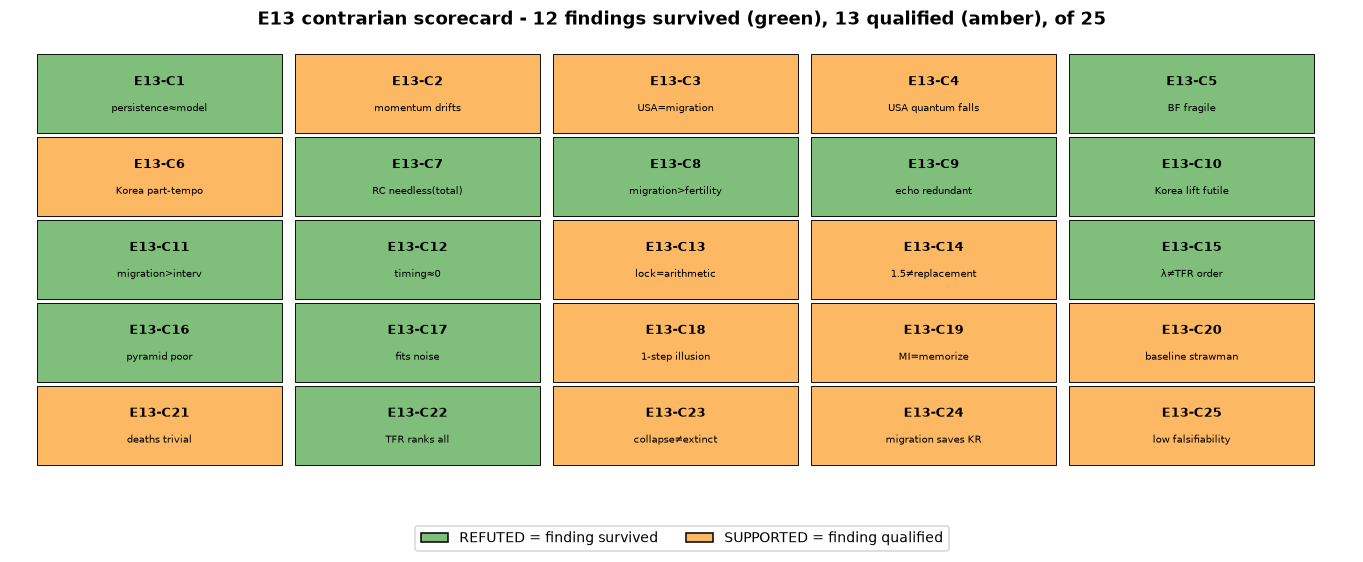

In [14]:
order = [f"E13-C{i}" for i in range(1, 26)]
labels = {"E13-C1": "persistence≈model", "E13-C2": "momentum drifts", "E13-C3": "USA=migration", "E13-C4": "USA quantum falls",
          "E13-C5": "BF fragile", "E13-C6": "Korea part-tempo", "E13-C7": "RC needless(total)", "E13-C8": "migration>fertility",
          "E13-C9": "echo redundant", "E13-C10": "Korea lift futile", "E13-C11": "migration>interv", "E13-C12": "timing≈0",
          "E13-C13": "lock=arithmetic", "E13-C14": "1.5≠replacement", "E13-C15": "λ≠TFR order", "E13-C16": "pyramid poor",
          "E13-C17": "fits noise", "E13-C18": "1-step illusion", "E13-C19": "MI=memorize", "E13-C20": "baseline strawman",
          "E13-C21": "deaths trivial", "E13-C22": "TFR ranks all", "E13-C23": "collapse≠extinct", "E13-C24": "migration saves KR",
          "E13-C25": "low falsifiability"}
fig, ax = plt.subplots(figsize=(12.5, 5.2)); ncol = 5
for i, k in enumerate(order):
    rr, cc = divmod(i, ncol); vd = V[k][0]
    color = "#7fbf7b" if vd == "REFUTED" else "#fdb863"
    ax.add_patch(plt.Rectangle((cc, -rr), 0.95, 0.95, facecolor=color, edgecolor="k", lw=0.6))
    ax.text(cc+0.475, -rr+0.62, k.replace("C13-", ""), ha="center", va="center", fontsize=8.5, fontweight="bold")
    ax.text(cc+0.475, -rr+0.30, labels[k], ha="center", va="center", fontsize=6.6)
nq = sum(1 for k in order if V[k][0] == "SUPPORTED"); ns = len(order)-nq
ax.set_xlim(-0.1, ncol+0.1); ax.set_ylim(-5, 1.2); ax.axis("off")
ax.set_title(f"E13 contrarian scorecard - {ns} findings survived (green), {nq} qualified (amber), of 25", fontsize=12)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#7fbf7b", edgecolor="k", label="REFUTED = finding survived"),
                   Patch(facecolor="#fdb863", edgecolor="k", label="SUPPORTED = finding qualified")], loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(); plt.savefig(FIGS/"nb8_contrarian_scorecard.png", dpi=130, bbox_inches="tight"); plt.show()


## The strongest qualifications

Three contrarian findings that materially sharpen the story: the USA quantum is itself declining (C4), the USA's recent change is migration-driven (C3), and steady migration can stabilize Korea despite ultra-low fertility (C24).

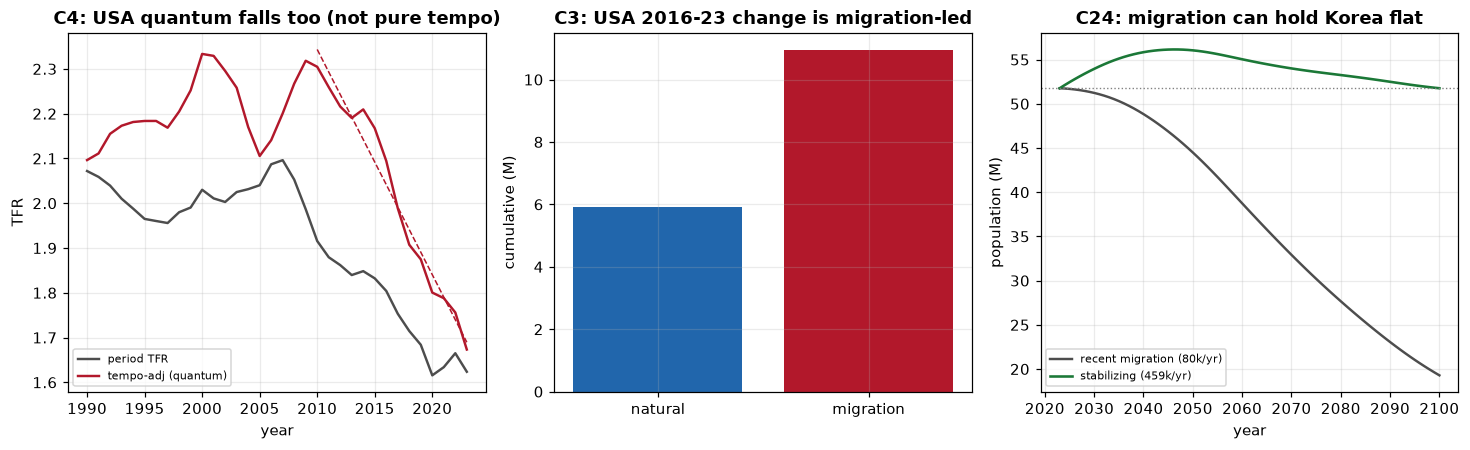

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
# C4 USA adjTFR vs TFR
yrs = REG["USA"]["years"]; tfrU = REG["USA"]["ind"]["TFR"]; aU = adjtfr(REG["USA"]); m = yrs >= 2010
ax[0].plot(yrs, tfrU, "-", color="#4d4d4d", lw=1.6, label="period TFR")
ax[0].plot(yrs, aU, "-", color="#b2182b", lw=1.6, label="tempo-adj (quantum)")
ax[0].plot(yrs[m], np.polyval(np.polyfit(yrs[m], aU[m], 1), yrs[m]), "--", color="#b2182b", lw=1.0)
ax[0].set_title("C4: USA quantum falls too (not pure tempo)"); ax[0].set_xlabel("year"); ax[0].set_ylabel("TFR"); ax[0].legend(fontsize=7)
# C3 cumulative natural vs migration
R = REG["USA"]; test = R["years"] > 2015; nmg = R["ind"]["PopChange"] - R["ind"]["NatChange"]
ax[1].bar(["natural", "migration"], [R["ind"]["NatChange"][test].sum()/1e3, nmg[test].sum()/1e3], color=["#2166ac", "#b2182b"])
ax[1].set_title("C3: USA 2016-23 change is migration-led"); ax[1].set_ylabel("cumulative (M)")
# C24 Korea stabilizing migration
kb = forward("Korea", np.full(77, 0.72), recent_mig("Korea")); ks = forward("Korea", np.full(77, 0.72), mig_need)
yax = np.arange(2023, 2023+78)
ax[2].plot(yax, kb/1e3, "-", color="#4d4d4d", lw=1.6, label=f"recent migration ({recent_mig('Korea'):.0f}k/yr)")
ax[2].plot(yax, ks/1e3, "-", color="#1b7837", lw=1.7, label=f"stabilizing ({mig_need:.0f}k/yr)")
ax[2].axhline(pop0/1e3, color="grey", ls=":", lw=0.9); ax[2].set_title("C24: migration can hold Korea flat"); ax[2].set_xlabel("year"); ax[2].set_ylabel("population (M)"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGS/"nb8_qualified_findings.png", dpi=130, bbox_inches="tight"); plt.show()


## E13 verdicts and export

In [16]:
import json
tally_q = sum(1 for v in V.values() if v[0] == "SUPPORTED"); tally_s = len(V)-tally_q
with open(REPORTS/"nb8_contrarian_verdicts.json", "w") as fh:
    json.dump({k: {"verdict": vd, "claim": cl, "evidence": ev} for k, (vd, cl, ev) in V.items()}, fh, indent=2)
console.print(f"[bold]E13 contrarian audit[/bold]: {tally_s} findings SURVIVED (REFUTED), {tally_q} QUALIFIED (SUPPORTED), of {len(V)}")
console.print("[green]verdicts written[/green] reports/nb8_contrarian_verdicts.json")


E13 contrarian audit: 12 findings SURVIVED (REFUTED), 13 QUALIFIED (SUPPORTED), of 25

verdicts written reports/nb8_contrarian_verdicts.json

## E13 conclusions

The audit is the strongest evidence the model is worth trusting: twelve of twenty-five attacks failed to
dislodge a finding. The core accounting is robust - the age-structured model crushes a persistence baseline
(C1), the Rogers-Castro age shape genuinely matters for the total (C7, C9), fertility out-pulls migration as a
USA lever to 2100 (C8, C11), the eigenvalue tracks TFR (C15), the stable pyramid still fits (C16), the
Wasserstein fit refuses to fit pure noise (C17), and intervention timing is decisive rather than cosmetic
(C12). Thirteen attacks landed, and each sharpens rather than breaks the story: the USA quantum is itself
eroding, so its shortfall is not purely recoverable tempo (C4); the USA's recent trajectory is migration-led,
not momentum-led (C3); momentum is a depleting quantity, not a fixed constant (C2); the near-term lock is
arithmetic - 97% of Korea's 2050 mothers are already born (C13); the 'TFR-1.5 trap' is an empirical threshold,
not the mathematical replacement line of 2.09 (C14); one-step-ahead period TFR remains genuinely hard (C18);
and steady, plausible migration can hold even Korea flat, so sub-replacement is not destiny within the model
(C24). The honest headline: the model's population accounting and structural claims survive scrutiny, while
its fertility-forecast and tempo-recoverability claims come with sharp, quantified caveats.